# Acrobot (2-DoF manipulator) — unconstrained reach-avoid backstepping controller


In [1]:
import sympy as sp

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from acrobot_inverse_kinematics import inverse_kinematics
from functional import BetterColor

# ── Load k1 polynomial and parameters from k1_acrobot_cdc2026.py ─────────────
from k1_acrobot_cdc2026 import (
    k1_0 as _k1_0_raw,
    k1_1 as _k1_1_raw,
    y as y_cdc,  # y_cdc[0], y_cdc[1] — output-space symbols in that file
    val_lambda,
    val_delta,
)

print(
    f"Loaded k1 from k1_acrobot_cdc2026.py  (val_lambda={val_lambda}, val_delta={val_delta})"
)

# ── Symbolic variables ────────────────────────────────────────────────────────
x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, x3, x4]  # [q1, q2, dq1, dq2]

# ── Physical parameters ───────────────────────────────────────────────────────
m1, m2 = 1.0, 1.0
l1, l2 = 4.0, 4.0
lc1, lc2 = 2.0, 2.0
I1, I2 = 0.02, 0.02
g_grav = 9.81

# ── Acrobot dynamics  xdot = f(x) + g_mat(x)*u ───────────────────────────────
M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * sp.cos(x2))
M12 = m2 * (lc2**2 + l1 * lc2 * sp.cos(x2)) + I2
M22 = m2 * lc2**2 + I2
M_sym = sp.Matrix([[M11, M12], [M12, M22]])
Minv_sym = M_sym.inv()

C_sym = sp.Matrix(
    [
        [-m2 * l1 * lc2 * sp.sin(x2) * x4, -m2 * l1 * lc2 * sp.sin(x2) * (x3 + x4)],
        [m2 * l1 * lc2 * sp.sin(x2) * x3, sp.Integer(0)],
    ]
)

G_sym = sp.Matrix(
    [
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * sp.cos(x1)
        + m2 * g_grav * lc2 * sp.cos(x1 + x2),
        m2 * g_grav * lc2 * sp.cos(x1 + x2),
    ]
)

qdot_sym = sp.Matrix([x3, x4])
f_sym = sp.Matrix([x3, x4]).col_join(Minv_sym @ (-C_sym @ qdot_sym - G_sym))
g_mat = sp.Matrix([[0, 0], [0, 0]]).col_join(Minv_sym)

# ── Output map: end-effector Cartesian position ───────────────────────────────
hx = sp.Matrix(
    [l1 * sp.cos(x1) + l2 * sp.cos(x1 + x2), l1 * sp.sin(x1) + l2 * sp.sin(x1 + x2)]
)

# ── Sets in output (y) space ─────────────────────────────────────────────────
psi_y = -((4 * (y1 - 2) - 2 * y2**3) ** 2) + 0.8 * y2**3 + 10  # safe set  >= 0
phi_y = (
    ((y1 - 2 - 3.5) ** 2 / 1.2**2) + ((y2 - 1.8) ** 2 / 0.4**2) - 2
)  # target set <= 0

psi_x = psi_y.subs({y1: hx[0], y2: hx[1]})
phi_x = phi_y.subs({y1: hx[0], y2: hx[1]})

# ── Backstepping controller construction (method from example_acrobot_cdc2025) ─
# k1 is expressed in y_cdc[0], y_cdc[1] — substitute into y1, y2 for later use
subs_cdc_to_y = {y_cdc[0]: y1, y_cdc[1]: y2}
k1_opt = sp.Matrix(
    [_k1_0_raw.subs(subs_cdc_to_y), _k1_1_raw.subs(subs_cdc_to_y)]
)  # in y1, y2

# Lie derivatives of h along f and g  (all in x1..x4)
Lfh = hx.jacobian(state_vars) @ f_sym  # (2,1)  L_f h
F_2 = Lfh.jacobian(state_vars) @ f_sym  # (2,1)  L^2_f h
G_2 = Lfh.jacobian(state_vars) @ g_mat  # (2,2)  L_g L_f h

# Safe-set gradient in y-space
Dy_psi_y = sp.Matrix([psi_y]).jacobian([y1, y2])  # (1,2)

mu_1 = 15

# Four backstepping terms (initially mixed x / y1,y2 variables)
item1 = -F_2
item2 = mu_1 * Dy_psi_y.T
item3 = k1_opt.jacobian([y1, y2]) @ Lfh
item4 = val_lambda / 2 * (Lfh - k1_opt)

# Substitute y1, y2 → hx (map output space to joint space)
subs_y_to_x = {y1: hx[0], y2: hx[1]}
item2 = item2.subs(subs_y_to_x)
item3 = item3.subs(subs_y_to_x)
item4 = item4.subs(subs_y_to_x)

u_opt = sp.Matrix(sp.inv_quick(G_2) @ (item1 + item2 + item3 + item4))

# Reach-avoid certificate: V(x) = psi(y(x)) - 1/(2*mu_1) * ||L_f h(x) - k1(y(x))||^2
Lfh_minus_k1 = Lfh - k1_opt.subs(subs_y_to_x)
certificate_opt = (
    psi_x - sp.Integer(1) / (2 * mu_1) * (Lfh_minus_k1.T @ Lfh_minus_k1)[0, 0]
)
print("u_opt constructed.  Free symbols:", u_opt[0].free_symbols)
print("certificate_opt free symbols:    ", certificate_opt.free_symbols)

# ── Numpy callables ───────────────────────────────────────────────────────────
psi_y_func = sp.lambdify([y1, y2], psi_y, "numpy")
phi_y_func = sp.lambdify([y1, y2], phi_y, "numpy")
psi_x_func = sp.lambdify(state_vars, psi_x, "numpy")
phi_x_func = sp.lambdify(state_vars, phi_x, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")
cert_func = sp.lambdify(state_vars, certificate_opt, "numpy")
k1_func = sp.lambdify([y1, y2], list(k1_opt), "numpy")

print("State:", state_vars)
print("h(x):", hx.T)
print("psi_y:", psi_y)
print("phi_y:", phi_y)

Loaded k1 from k1_acrobot_cdc2026.py  (val_lambda=2.0731e-06, val_delta=5.2608e-11)
u_opt constructed.  Free symbols: {x3, x4, x2, x1}
certificate_opt free symbols:     {x3, x4, x2, x1}
State: [x1, x2, x3, x4]
h(x): Matrix([[4.0*cos(x1) + 4.0*cos(x1 + x2), 4.0*sin(x1) + 4.0*sin(x1 + x2)]])
psi_y: 0.8*y2**3 - (4*y1 - 2*y2**3 - 8)**2 + 10
phi_y: 0.694444444444444*(y1 - 5.5)**2 + 6.25*(y2 - 1.8)**2 - 2


In [3]:
# ── Sample in y-space via inverse kinematics  (same strategy as vanilla MPC) ──
# NOTE: The backstepping controller is valid away from kinematic singularities.
# The end-effector Jacobian det(J_h) = l1*l2*sin(x2) vanishes at x2 = 0 and x2 = π.
# We enforce |sin(x2)| > sin_min to stay in the controller's valid domain.
sin_min = 0.15  # minimum |sin(x2)| — excludes x2 within ~8.6° of 0 or π

N_samples = 2000
N_candidates_max = 100
np.random.seed(42)

y1_samp = np.random.uniform(-1.0, 5.5, N_samples)
y2_samp = np.random.uniform(-4.0, 3.1, N_samples)

# IK: elbow-up solution; qdot = 0
x_list = []
for i in range(N_samples):
    r2 = y1_samp[i] ** 2 + y2_samp[i] ** 2
    if r2 > (l1 + l2) ** 2 or r2 < 1e-4:
        x_list.append([np.nan] * 4)
        continue
    try:
        (q1, q2), _ = inverse_kinematics(y1_samp[i], y2_samp[i], l1, l2)
        x_list.append(
            [q1, q2, 0.0, 0.0]
            if (np.isfinite(q1) and np.isfinite(q2))
            else [np.nan] * 4
        )
    except Exception:
        x_list.append([np.nan] * 4)

x_samples = np.array(x_list).T  # (4, N_samples)
valid_ik = np.all(np.isfinite(x_samples), axis=0)

psi_vals = np.where(
    valid_ik, np.atleast_1d(np.squeeze(psi_x_func(*x_samples))), -np.inf
)
phi_vals = np.where(
    valid_ik, np.atleast_1d(np.squeeze(phi_x_func(*x_samples))), -np.inf
)
cert_vals = np.where(
    valid_ik, np.atleast_1d(np.squeeze(cert_func(*x_samples))), -np.inf
)
sin_x2_vals = np.where(valid_ik, np.abs(np.sin(x_samples[1, :])), 0.0)

# Step 1: candidates = safe AND outside target AND away from kinematic singularity
candidate_mask = (psi_vals >= 0) & (phi_vals > 0) & (sin_x2_vals > sin_min)
candidate_idx = np.where(candidate_mask)[0][:N_candidates_max]
print(
    f"Candidates (safe & outside target & |sin(x2)|>{sin_min}, capped): {len(candidate_idx)} / {N_samples}"
)

# Step 2: valid = candidates with cert V(x) >= 0
valid_mask = np.zeros(N_samples, dtype=bool)
valid_mask[candidate_idx] = cert_vals[candidate_idx] >= 0
valid_idx = np.where(valid_mask)[0]
x_valid = x_samples[:, valid_idx]
print(f"Valid (cert >= 0): {len(valid_idx)} / {len(candidate_idx)} candidates")
print(
    f"|sin(x2)| range of valid ICs: [{sin_x2_vals[valid_idx].min():.3f}, {sin_x2_vals[valid_idx].max():.3f}]"
)

Candidates (safe & outside target & |sin(x2)|>0.15, capped): 100 / 2000
Valid (cert >= 0): 67 / 100 candidates
|sin(x2)| range of valid ICs: [0.340, 0.895]


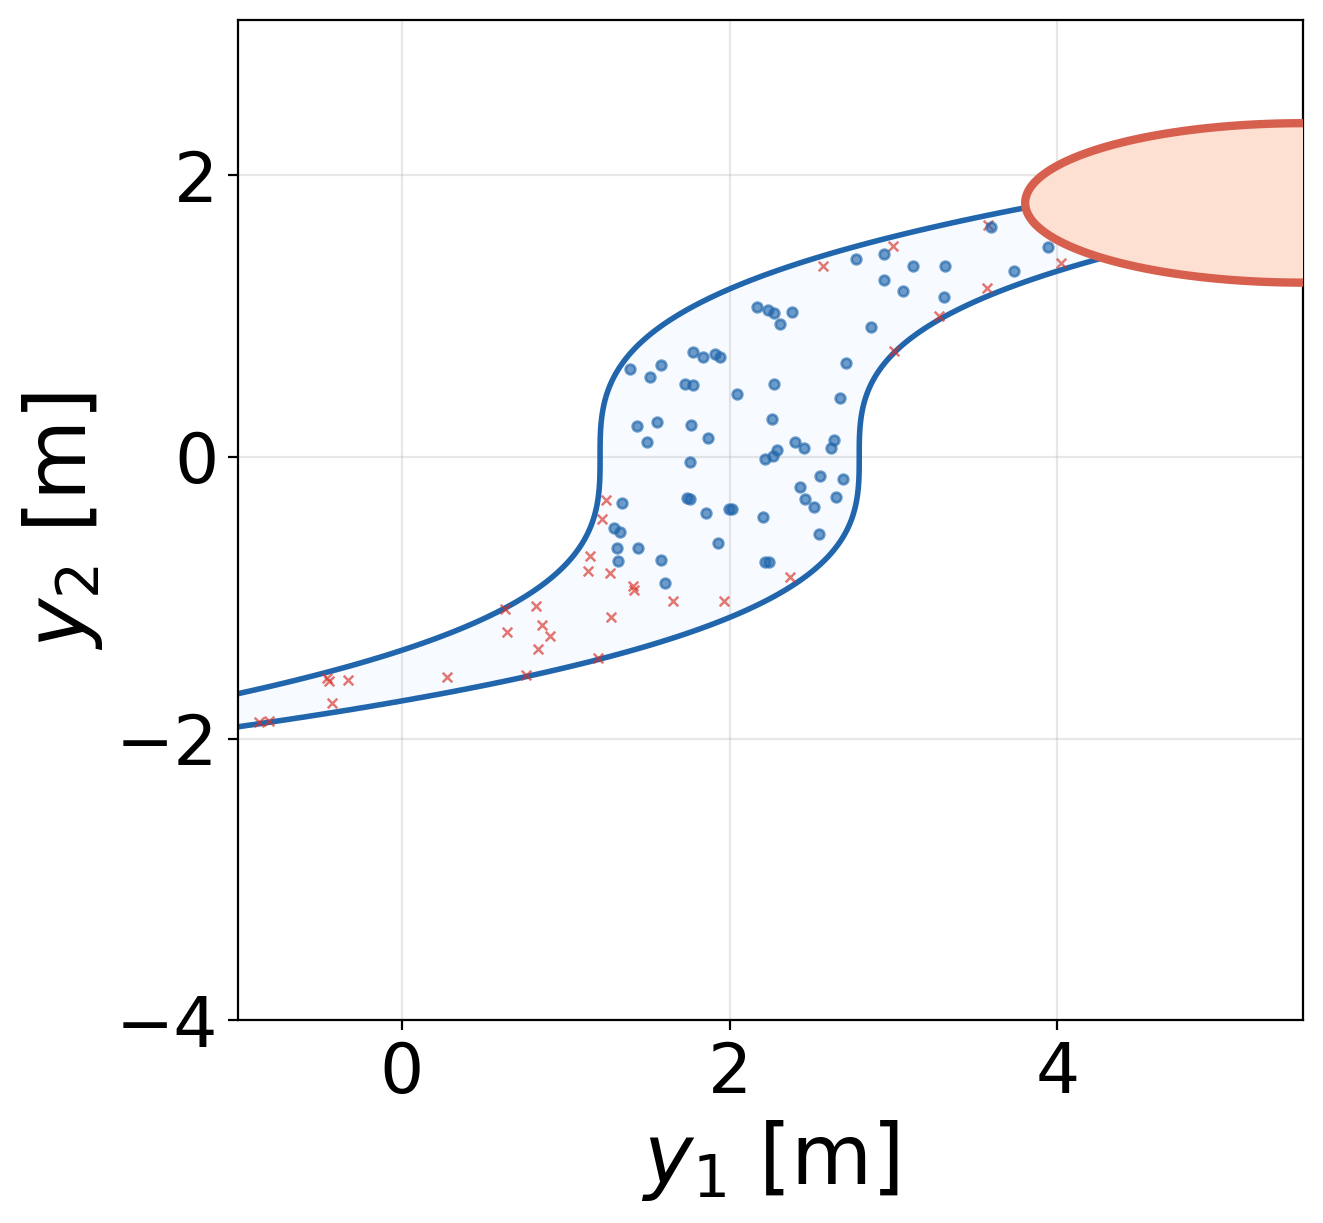

In [4]:
# ── Visualise cert-feasible / cert-infeasible initial states ──────────────────
feasible_idx = candidate_idx[cert_vals[candidate_idx] >= 0]
infeasible_idx = candidate_idx[cert_vals[candidate_idx] < 0]

y_feasible = np.array([y1_samp[feasible_idx], y2_samp[feasible_idx]])
y_infeasible = np.array([y1_samp[infeasible_idx], y2_samp[infeasible_idx]])

n_grid = 400
Y1g, Y2g = np.meshgrid(np.linspace(-1, 5.5, n_grid), np.linspace(-4, 3.1, n_grid))
Z_psi = psi_y_func(Y1g, Y2g)
Z_phi = phi_y_func(Y1g, Y2g)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

ax.contourf(
    Y1g, Y2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1g, Y2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
ax.contourf(
    Y1g, Y2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1g, Y2g, Z_phi, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=12,
    color="#d73027",
    alpha=0.65,
    marker="x",
    linewidths=0.9,
    label=f"Infeasible (cert < 0): {len(infeasible_idx)}",
    zorder=9,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=12,
    color="#2166ac",
    alpha=0.65,
    marker="o",
    label=f"Feasible (cert ≥ 0): {len(feasible_idx)}",
    zorder=10,
)

fs = 30
ax.set_xlabel("$y_1$ [m]", fontsize=fs)
ax.set_ylabel("$y_2$ [m]", fontsize=fs)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
plt.show()

In [5]:
# ── Build closed-loop dynamics and lambdify ───────────────────────────────────
cl_dyn = f_sym + g_mat @ u_opt
dyn_cl_f = sp.lambdify(state_vars, cl_dyn, "numpy")
print("Closed-loop state dimension:", cl_dyn.shape)

Closed-loop state dimension: (4, 1)


In [6]:
# ── Simulate closed-loop trajectories (RK4, same approach as example_acrobot_cdc2025) ─
from functional import simulate as rk4_step

dt = 0.01
n_sub = 3  # odeint sub-steps inside each dt (same as cdc2025)
max_steps = 2000  # T_max = max_steps * dt = 20 s
sin_tol = 0.05  # stop if kinematic singularity |sin(x2)| < sin_tol
N_sim_max = 10  # cap: only simulate the first N_sim_max valid ICs

n_sim = min(N_sim_max, x_valid.shape[1])
print(f"Simulating {n_sim} / {x_valid.shape[1]} valid ICs (N_sim_max={N_sim_max}) ...")

traj_t, traj_x, traj_y = [], [], []
n_failed = 0

for i in range(n_sim):
    x_cur = x_valid[:, i].reshape(1, -1)  # (1, 4)

    this_t = [0.0]
    this_x = [x_cur.flatten()]
    this_y = [np.array(hx_func(*x_cur.T)).flatten()]

    phi_val = float(np.squeeze(phi_x_func(*x_cur.T)))
    step = 0

    while phi_val > 0 and step < max_steps:
        # stop if approaching kinematic singularity (det J_h = l1*l2*sin(x2) → 0)
        if abs(np.sin(x_cur[0, 1])) < sin_tol:
            break

        x_next = rk4_step(dyn_cl_f, x_cur, dt, n_sub)

        if not np.all(np.isfinite(x_next)):
            break

        phi_val = float(np.squeeze(phi_x_func(*x_next.T)))
        step += 1

        this_t.append(step * dt)
        this_x.append(x_next.flatten())
        this_y.append(np.array(hx_func(*x_next.T)).flatten())

        x_cur = x_next

    if phi_val <= 0:  # reached target
        traj_t.append(np.array(this_t))
        traj_x.append(np.array(this_x))  # (N, 4)
        traj_y.append(np.array(this_y))  # (N, 2)
    else:
        n_failed += 1

print(
    f"Reached target: {len(traj_t)} / {n_sim}   (failed/singularity/timeout: {n_failed})"
)

Simulating 10 / 67 valid ICs (N_sim_max=10) ...
Reached target: 8 / 10   (failed/singularity/timeout: 2)


Kept 3 / 8 trajectories (T_min=2 s filter)


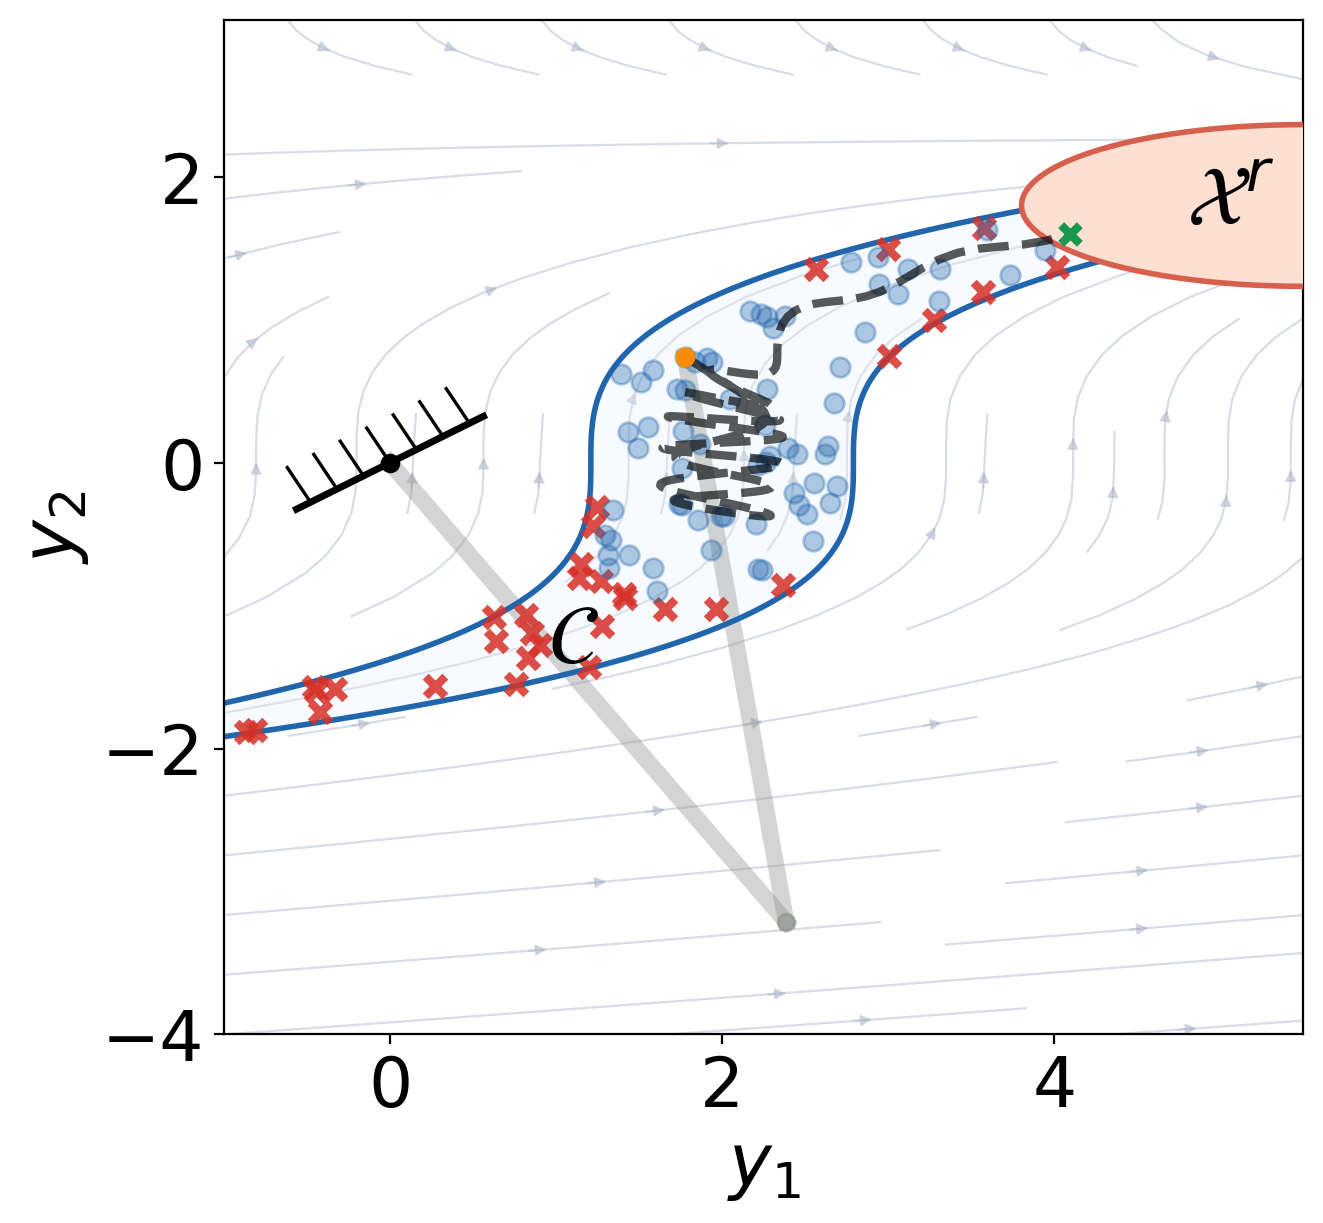

In [17]:
# ── Filter + visualise closed-loop trajectories ────────────────────────────────
T_max = max_steps * dt
T_min = 2  # ignore trivially short trajectories (already started inside target)

# All stored trajectories have already reached the target (phi <= 0 at end).
# Apply only T_min guard to remove any that were already inside target at t=0.
filtered = [
    (tt, tx, ty) for tt, tx, ty in zip(traj_t, traj_x, traj_y) if tt[-1] >= T_min
]
print(f"Kept {len(filtered)} / {len(traj_t)} trajectories (T_min={T_min} s filter)")

# only plot 1 trajectory for better visibility
filtered = filtered[2:3]

traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

# ── Grid for set contours ─────────────────────────────────────────────────────
n_grid = 400
Y1g, Y2g = np.meshgrid(np.linspace(-1, 5.5, n_grid), np.linspace(-4, 3.1, n_grid))
Z_psi = psi_y_func(Y1g, Y2g)
Z_phi = phi_y_func(Y1g, Y2g)

# ── k1 vector field ───────────────────────────────────────────────────────────
vf_y1 = np.linspace(-1, 5.5, 22)
vf_y2 = np.linspace(-4, 3.1, 22)
VF_Y1, VF_Y2 = np.meshgrid(vf_y1, vf_y2)
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()  # (2, n, n)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Vector field
ax.streamplot(
    vf_y1,
    vf_y2,
    k1_vals[0],
    k1_vals[1],
    density=0.6,
    color=BetterColor.gray0(0.5),
    linewidth=0.8,
    arrowsize=0.8,
    zorder=0,
)

# Safe region
ax.contourf(
    Y1g, Y2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1g, Y2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1g, Y2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1g, Y2g, Z_phi, levels=[0], colors=["#d6604d"], linewidths=2, zorder=4)

# Feasible / infeasible scatter
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=50,
    color="#d73027",
    alpha=0.85,
    marker="x",
    linewidths=3,
    label=f"Infeasible (cert < 0): {len(infeasible_idx)}",
    zorder=6,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=50,
    color="#2166ac",
    alpha=0.35,
    marker="o",
    label=f"Feasible (cert ≥ 0): {len(feasible_idx)}",
    zorder=7,
)

# Closed-loop trajectories
for ty, tx in zip(traj_y_plot, traj_x_plot):
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=3, alpha=0.65, zorder=10, linestyle="--"
    )
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=45,
        c=[BetterColor.orange3()],
        marker="o",
        linewidths=0.4,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=45,
        c=[BetterColor.green0()],
        marker="x",
        linewidths=3.0,
        zorder=20,
    )
    # Initial arm configuration
    q1i, q2i = tx[0, 0], tx[0, 1]
    jx = l1 * np.cos(q1i)
    jy = l1 * np.sin(q1i)
    ex = jx + l2 * np.cos(q1i + q2i)
    ey = jy + l2 * np.sin(q1i + q2i)
    ax.plot(
        [0, jx], [0, jy], "o-", alpha=0.4, lw=6, color=BetterColor.gray2(), zorder=1
    )
    ax.plot(
        [jx, ex], [jy, ey], "o-", alpha=0.4, lw=6, color=BetterColor.gray2(), zorder=1
    )

# ── Angled wall (30° from horizontal) supporting manipulator base ─────────────
wall_angle = 30
wall_hw = 0.65
tick_len = 0.28
n_ticks = 7
θ = np.radians(wall_angle)
wd = np.array([np.cos(θ), np.sin(θ)])
wp = np.array([-np.sin(θ), np.cos(θ)])
p0, p1 = -wall_hw * wd, wall_hw * wd
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "k-", lw=2.5, zorder=50)
for s in np.linspace(-wall_hw * 0.85, wall_hw * 0.85, n_ticks):
    base = s * wd
    tip = base + tick_len * wp
    ax.plot([base[0], tip[0]], [base[1], tip[1]], "k-", lw=1.2, zorder=50)
ax.plot(0, 0, "ko", markersize=6, zorder=51)

fs = 30
ax.text(0.95, -1.4, r"$\mathcal{C}$", zorder=100, fontsize=fs)
ax.text(4.8, 1.67, r"$\mathcal{X}^r$", zorder=1000, fontsize=fs)
ax.set_xlabel("$y_1$", fontsize=fs - 4)
ax.set_ylabel("$y_2$", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.set_xlim(-1, 5.5)
ax.set_ylim(-4, 3.1)
plt.show()

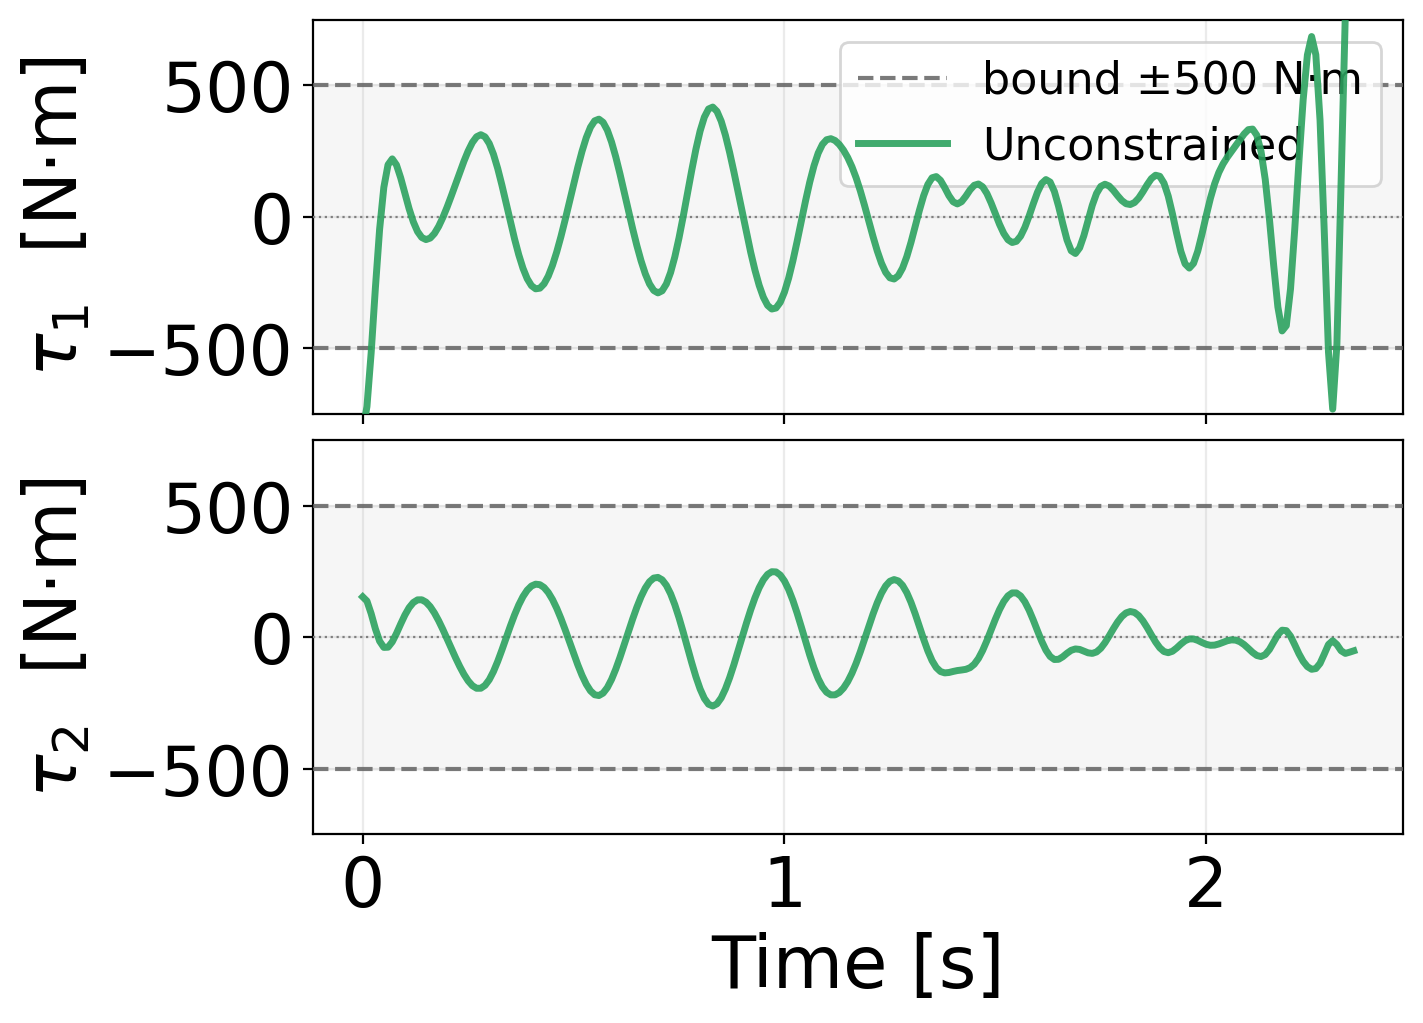

In [18]:
# ── Control inputs (torques) along filtered trajectories ─────────────────────
u1_func = sp.lambdify(state_vars, u_opt[0], "numpy")
u2_func = sp.lambdify(state_vars, u_opt[1], "numpy")

u_bound = 500.0  # [N·m]  — from the SOP bound enforcement

col_bound = "#636363"

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for ax in axes:
    ax.axhspan(-u_bound, u_bound, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(
        u_bound,
        color=col_bound,
        lw=1.5,
        ls="--",
        alpha=0.85,
        zorder=5,
        label=f"bound ±{u_bound:.0f} N·m",
    )
    ax.axhline(-u_bound, color=col_bound, lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)

for tt, tx in zip(traj_t_plot, traj_x_plot):
    axes[0].plot(
        tt,
        np.array(u1_func(*tx.T)).flatten(),
        lw=2.5,
        alpha=0.9,
        color="#2ca25f",
        zorder=10,
        label="Unconstrained",
    )
    axes[1].plot(
        tt,
        np.array(u2_func(*tx.T)).flatten(),
        lw=2.5,
        alpha=0.9,
        color="#2ca25f",
        zorder=10,
        label="Unconstrained",
    )

fs = 30
for ax, lbl in zip(axes, [r"$\tau_1$  [N·m]", r"$\tau_2$  [N·m]"]):
    ax.set_ylabel(lbl, fontsize=fs - 4)
    ax.xaxis.set_tick_params(labelsize=25)
    ax.yaxis.set_tick_params(labelsize=25)
    ax.grid(True, alpha=0.25)
    # set the y-limits to show the bound region clearly
    ax.set_ylim(-u_bound * 1.5, u_bound * 1.5)
axes[1].set_xlabel("Time [s]", fontsize=fs - 4)

handles, labels_ = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
axes[0].legend(by_label.values(), by_label.keys(), fontsize=16, loc="upper right")
plt.show()

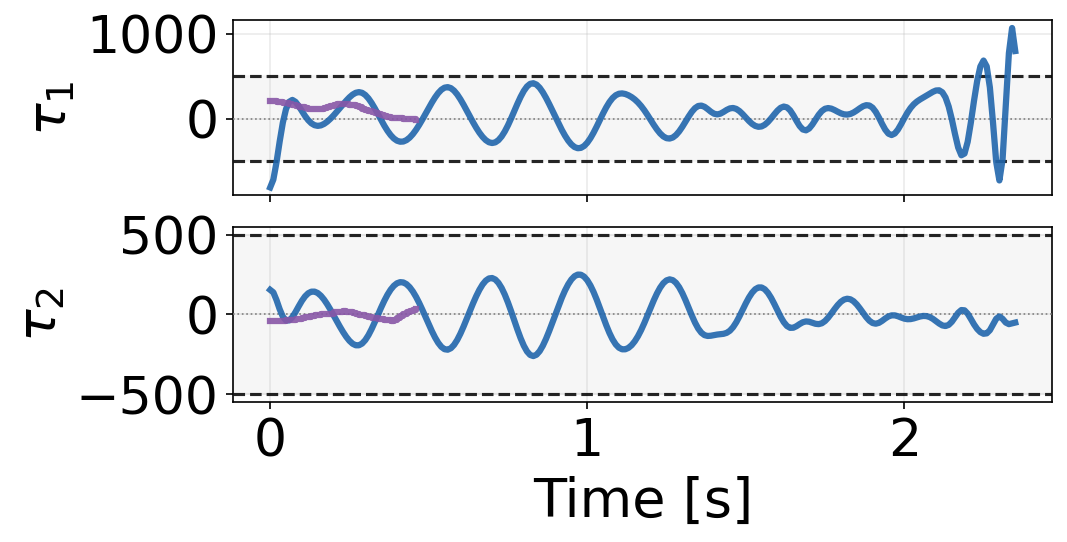

In [19]:
# ── Compare control inputs: unconstrained controller vs. RA-MPC ───────────────
# Mirrors example_dubins_car_unconstrained_reach_avoid.ipynb cell 6cbc610c.
# Run example_acrobot_reach_avoid_mpc.ipynb export cell first to generate
# traj_controls_ra_mpc_acrobot.npz.

ra_data = np.load("traj_controls_ra_mpc_acrobot.npz", allow_pickle=True)
v_traj_t = list(ra_data["traj_t"])
v_u1_traj = list(ra_data["u1_traj"])
v_u2_traj = list(ra_data["u2_traj"])
v_u_max = float(ra_data["u_max"][0])

u1_func = sp.lambdify(state_vars, u_opt[0], "numpy")
u2_func = sp.lambdify(state_vars, u_opt[1], "numpy")
u_bound = 500.0  # [N·m]  — SOP bound reference for unconstrained controller

col_uncon = "#2166ac"  # blue   — unconstrained controller
col_rampc = "#8856a7"  # purple — RA-MPC

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 350 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(150)

# ── Shaded feasible band ±u_bound ─────────────────────────────────────────────
for ax in axes:
    ax.axhspan(-u_bound, u_bound, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(u_bound, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(-u_bound, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)

# ── Unconstrained controller — continuous line ────────────────────────────────
for tt, tx in zip(traj_t_plot, traj_x_plot):
    axes[0].plot(
        tt,
        np.array(u1_func(*tx.T)).flatten(),
        lw=3,
        alpha=0.9,
        color=col_uncon,
        zorder=10,
        label="Unconstrained",
    )
    axes[1].plot(
        tt,
        np.array(u2_func(*tx.T)).flatten(),
        lw=3,
        alpha=0.9,
        color=col_uncon,
        zorder=10,
        label="Unconstrained",
    )

# ── RA-MPC — piecewise-constant step plot ─────────────────────────────────────
for tt, u1, u2 in zip(v_traj_t, v_u1_traj, v_u2_traj):
    t_steps = tt[:-1]  # control is held over [t_k, t_{k+1})
    axes[0].step(
        t_steps,
        u1,
        lw=3,
        alpha=0.9,
        color=col_rampc,
        where="post",
        zorder=10,
        label="RA-MPC",
    )
    axes[1].step(
        t_steps,
        u2,
        lw=3,
        alpha=0.9,
        color=col_rampc,
        where="post",
        zorder=10,
        label="RA-MPC",
    )

# ── Decorations ───────────────────────────────────────────────────────────────
fs = 30
for ax, lbl in zip(axes, [r"$\tau_1$", r"$\tau_2$"]):
    ax.set_ylabel(lbl, fontsize=fs - 4)
    ax.xaxis.set_tick_params(labelsize=25)
    ax.yaxis.set_tick_params(labelsize=25)
    ax.grid(True, alpha=0.25)

axes[1].set_xlabel("Time [s]", fontsize=fs - 4)

# Deduplicated legend on top axes
handles, labels_ = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
# axes[0].legend(by_label.values(), by_label.keys(), fontsize=16, loc="upper right")

plt.show()